**[Text 01]**

# Nash Equilibrium From Scratch

Fictitious play, gradient descent–ascent, and extragradient on two games small enough to audit line by line. We will measure exploitability rather than infer convergence from a flat loss or a stable-looking trajectory.

Companions: [Game Theory for ML Practitioners](https://artifocial.com/blog/game-theory-for-ml-2026-sep-02), the basics piece this notebook implements, and the W35 flagship [The Game Inside the Network](https://artifocial.com/blog/game-inside-the-network-2026-aug-28). Background: [Deep Fictitious Play](https://arxiv.org/abs/1903.09376). Runtime: under one minute on CPU.

In [1]:
# [Code 01]
import shutil
import subprocess
import sys

# uv-first: use uv if available, fall back to pip
if shutil.which("uv"):
    subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", "numpy", "matplotlib"])
else:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"])

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Setup complete!")
print(f"NumPy version: {np.__version__}")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /private/tmp/art1536-nbqa/bin/python -m pip install --upgrade pip


Setup complete!
NumPy version: 2.5.2


**[Text 02]**

## Exploitability is the test

For a zero-sum payoff matrix $A$, row strategy $p$, and column strategy $q$, the row player receives $p^\top A q$. The sum of both players' profitable unilateral deviations is

$$\epsilon(p,q)=\max_i (Aq)_i- p^\top A q + p^\top A q-\min_j(p^\top A)_j.$$

The middle terms cancel, but keeping them visible makes the two deviations explicit. Zero means neither player can improve alone.

In [2]:
# [Code 02]
def normalize(x):
    x = np.asarray(x, dtype=float)
    return x / x.sum()

def exploitability(A, p, q):
    value = p @ A @ q
    row_gain = np.max(A @ q) - value
    col_gain = value - np.min(p @ A)
    return row_gain + col_gain

matching_pennies = np.array([[1.0, -1.0], [-1.0, 1.0]])
rock_paper_scissors = np.array([[0.0, -1.0, 1.0], [1.0, 0.0, -1.0], [-1.0, 1.0, 0.0]])
for name, A in [("matching pennies", matching_pennies), ("rock-paper-scissors", rock_paper_scissors)]:
    uniform = np.ones(len(A)) / len(A)
    print(f"{name:20s} uniform exploitability = {exploitability(A, uniform, uniform):.3f}")

matching pennies     uniform exploitability = 0.000
rock-paper-scissors  uniform exploitability = 0.000


**[Text 03]**

## Fictitious play: best-respond to history

Each player best-responds to the opponent's empirical action frequencies. The current pure actions can cycle forever; the empirical mixtures are the object whose exploitability should fall. We add one pseudocount per action so the first response is defined without special cases.

In [3]:
# [Code 03]
def fictitious_play(A, steps=5000):
    n_row, n_col = A.shape
    row_counts = np.ones(n_row)
    col_counts = np.ones(n_col)
    history = []
    for t in range(steps):
        p, q = normalize(row_counts), normalize(col_counts)
        # Deterministic tie cycling avoids making the illustration depend on argmax's first index.
        row_values = A @ q
        col_values = p @ A
        row_candidates = np.flatnonzero(np.isclose(row_values, row_values.max()))
        col_candidates = np.flatnonzero(np.isclose(col_values, col_values.min()))
        row_action = row_candidates[t % len(row_candidates)]
        col_action = col_candidates[t % len(col_candidates)]
        row_counts[row_action] += 1
        col_counts[col_action] += 1
        if t == 0 or (t + 1) % 10 == 0:
            p, q = normalize(row_counts), normalize(col_counts)
            history.append((t + 1, p.copy(), q.copy(), exploitability(A, p, q)))
    return history

histories = {"Matching pennies": fictitious_play(matching_pennies),
             "Rock-paper-scissors": fictitious_play(rock_paper_scissors)}
for name, history in histories.items():
    step, p, q, eps = history[-1]
    print(f"{name}: step={step}, p={np.round(p, 3)}, q={np.round(q, 3)}, exploitability={eps:.4f}")

Matching pennies: step=5000, p=[0.495 0.505], q=[0.495 0.505], exploitability=0.0200
Rock-paper-scissors: step=5000, p=[0.34  0.327 0.333], q=[0.34  0.327 0.333], exploitability=0.0132


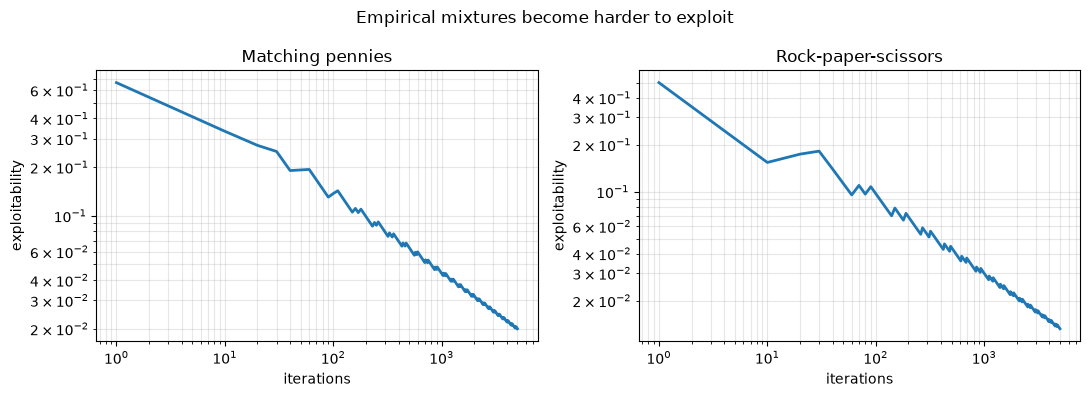

Matching pennies: exploitability fell from 0.667 to 0.0200.
Rock-paper-scissors: exploitability fell from 0.500 to 0.0132.


In [4]:
# [Result 01]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, history) in zip(axes, histories.items()):
    steps = np.array([h[0] for h in history])
    eps = np.array([h[3] for h in history])
    ax.loglog(steps, eps, lw=2)
    ax.set(title=name, xlabel="iterations", ylabel="exploitability")
    ax.grid(alpha=.3, which="both")
fig.suptitle("Empirical mixtures become harder to exploit")
plt.tight_layout()
plt.show()
for name, history in histories.items():
    first, last = history[0][3], history[-1][3]
    direction = "fell" if last < first else "did not fall"
    print(f"{name}: exploitability {direction} from {first:.3f} to {last:.4f}.")

**[Callout 01]**

> **Engineering Callout #1: Last iterate and average strategy are different estimators**
>
> Fictitious play deliberately emits a pure best response at each step. Plotting only that action makes a working solver look unstable. The empirical action counts define the mixed strategy, so we evaluate those counts. The general lesson is to match the convergence diagnostic to the theorem your algorithm actually supports.

**[Text 04]**

## A gradient game can rotate instead of descend

In $\min_x\max_y xy$, simultaneous gradient descent–ascent follows $F(x,y)=(y,-x)$. Its squared radius grows by $1+\eta^2$ per step, so its radius grows by $\sqrt{1+\eta^2}$. Extragradient probes the field once before committing. Here its squared-radius factor is $1-\eta^2+\eta^4$, which is below one when $0<\eta<1$; our $\eta=0.15$ therefore contracts.

In [5]:
# [Code 04]
def bilinear_dynamics(method, eta=0.15, steps=120, z0=(1.0, 0.4)):
    z = np.array(z0, dtype=float)
    path = [z.copy()]
    def F(v):
        return np.array([v[1], -v[0]])
    for _ in range(steps):
        if method == "simultaneous":
            z = z - eta * F(z)
        elif method == "extragradient":
            lookahead = z - eta * F(z)
            z = z - eta * F(lookahead)
        else:
            raise ValueError(method)
        path.append(z.copy())
    return np.array(path)

paths = {m: bilinear_dynamics(m) for m in ["simultaneous", "extragradient"]}
for method, path in paths.items():
    radii = np.linalg.norm(path, axis=1)
    print(f"{method:14s}: radius {radii[0]:.3f} -> {radii[-1]:.3f}")

simultaneous  : radius 1.077 -> 4.093
extragradient : radius 1.077 -> 0.284


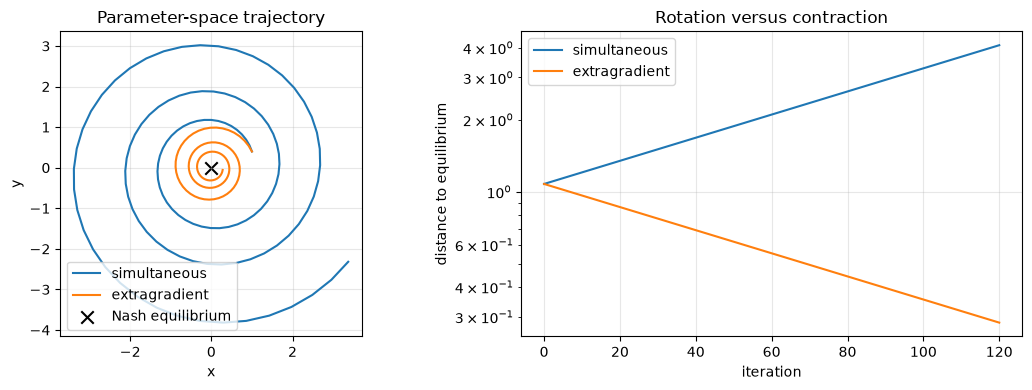

Extragradient ended closer to equilibrium.


In [6]:
# [Result 02]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method, path in paths.items():
    axes[0].plot(path[:, 0], path[:, 1], label=method)
    axes[1].semilogy(np.linalg.norm(path, axis=1), label=method)
axes[0].scatter([0], [0], marker="x", s=80, c="black", label="Nash equilibrium")
axes[0].set(xlabel="x", ylabel="y", title="Parameter-space trajectory", aspect="equal")
axes[1].set(xlabel="iteration", ylabel="distance to equilibrium", title="Rotation versus contraction")
for ax in axes:
    ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()
sim_end = np.linalg.norm(paths["simultaneous"][-1])
extra_end = np.linalg.norm(paths["extragradient"][-1])
print("Extragradient ended closer to equilibrium." if extra_end < sim_end else "Extragradient did not improve this run; inspect eta.")

**[Callout 02]**

> **Engineering Callout #2: A loss curve is not an equilibrium certificate**
>
> In a multi-player system, each loss is evaluated against a moving opponent. The parameter trajectory can spiral even when short windows of either loss look flat. Track a deviation metric such as exploitability when it is computable, and pair it with parameter-space diagnostics when it is not.

**[Text 05]**

## What we built

In these two finite zero-sum examples, we implemented fictitious play and observed its empirical mixtures approach the known equilibria. Fictitious play does not converge in every game, so falling exploitability is evidence for these runs rather than a universal guarantee. We then reproduced the rotational failure mode of naive gradients and the contraction created by extragradient.

Everything above computed exploitability with an exact `max`, which is the luxury of a payoff matrix. Production neural games replace that exact best response with a *learned* one, and the substitution changes how the number should be read: what gets reported is the gain of the strongest response the search happened to find, so it is a lower bound on true exploitability. A high value is trustworthy — a deviation that was found exists. A low value is the untrustworthy direction, equally consistent with a robust policy and with an attacker given too little compute.

So the audit becomes stricter, not merely larger: report opponent distributions, regret or exploitability proxies, seed variation, held-out adversaries, and the response-learner budget that produced each exploitability number. Without that last field the metric cannot be compared across runs.

Next: the companion notebook builds a self-play population and asks whether its verifier supplies real improvement signal or merely rewards its own noise.